In [1]:
import torch
import numpy as np
from load_dataset import LoadDataset
from model import MLP
from torch.utils.data import DataLoader
from training import Trainer
from metrics import Evaluator
from gradients import GradMonitor 
import matplotlib.pyplot as plt  

In [2]:
iris_path = '/home/jessica/Documentos/pesquisa/knowledge_distillation/dataset/Iris.csv'
iris = LoadDataset(iris_path)
iris.load()
train_data, test_data = iris.split_dataset()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jessica/Documentos/pesquisa/knowledge_distillation/dataset/Iris.csv'

In [ ]:
iris_path = '/home/jessica/Documentos/pesquisa/knowledge_distillation/dataset/Iris.csv'
iris = LoadDataset(iris_path)
iris.load()
train_data, test_data = iris.split_dataset()

FileNotFoundError: [Errno 2] No such file or directory: '/home/jessica/Documentos/pesquisa/knowledge_distillation/dataset/Iris.csv'

In [5]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [6]:
config_prof = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5,5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
teacher = MLP(config_prof).to(device)
trainer = Trainer(teacher, config_prof)
epochs = 1000
ptrain_old = Evaluator(teacher).accuracy(train_loader)
patience = 0
for _ in range(epochs):
    trainer.train_epoch(train_loader)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    if abs(ptrain_old - ptrain) < 1e-3:  # Convergence check
        patience += 1
    else:
        patience = 0
    ptrain_old = ptrain
    if patience >= 60:  # Early stopping after 5 epochs without improvement
        print(f"Early stopping at epoch {_+1}")
        break
metrics = Evaluator(teacher)
print(metrics.accuracy(train_loader), metrics.accuracy(test_loader))
teacher_monitor = GradMonitor(teacher, config_prof)
log_teacher = teacher_monitor.get_gradients(train_loader)


Early stopping at epoch 258
0.9809523809523809 0.9111111111111111


In [8]:
def get_student_model(T, c, teacher, train_loader, config, max_epochs=20000, patience=100, tol=1e-5):
    student = MLP(config).to(device)
    t_student = Trainer(student, config)
    ptrain = Evaluator(teacher).accuracy(train_loader)
    sold = ptrain
    patience = 0
    for k in range(max_epochs):
        t_student.train_student(teacher, train_loader, T=T, c=c)
        strain = Evaluator(student).accuracy(train_loader)
        if (abs(sold - strain)) < tol:  # Convergence check
           patience += 1
        else:
           patience = 0
       
        if patience >= 50:  # Early stopping after 5 epochs without improvement
            break
        sold = strain
    return student, k

##### Será que as informações dentro as redes sao iguais? -> vou dar uma olhada nos gradientes
---

In [40]:
config_student = {
    'input_dim': 4,
    'in_channels': 1,   
    'output_dim': 3,     # RGB
    'fc': [5],
    'criterion':  torch.nn.CrossEntropyLoss(),
    'optimizer':  torch.optim.Adam,
    'lr': 0.001
}

In [50]:
student, epochs = get_student_model(T=5, c=0.5, teacher=teacher, train_loader=train_loader, config=config_student)
student_monitor = GradMonitor(student, config_student)
log_student = student_monitor.get_gradients(train_loader) 
metrics_student = Evaluator(student)
print(metrics_student.accuracy(train_loader), metrics_student.accuracy(test_loader))

0.8952380952380953 0.7777777777777778


In [51]:
teacher_info = {'grads' : {}, 'output':[]}
student_info = {'grads' : {}, 'output':[]}
for i in range(len(log_teacher)):
    for key in log_teacher[i]['grads']:
        if key not in teacher_info['grads']:
            teacher_info['grads'][key] = []
        
        teacher_info['grads'][key].append(log_teacher[i]['grads'][key])
        if key in log_student[i]['grads']:
            if key not in student_info['grads']:
                student_info['grads'][key] = []
            student_info['grads'][key].append(log_student[i]['grads'][key])
    teacher_info['output'].append(log_teacher[i]['pred_labels'])
    student_info['output'].append(log_student[i]['pred_labels'])

for key in teacher_info['grads']:
    teacher_info['grads'][key] = torch.cat(teacher_info['grads'][key], dim=0)
    if key in student_info['grads']:
        student_info['grads'][key] = torch.cat(student_info['grads'][key], dim=0)

teacher_info['output'] = torch.cat(teacher_info['output'], dim=0)
student_info['output'] = torch.cat(student_info['output'], dim=0)

In [52]:
idteacher = np.argsort(teacher_info['output'].cpu().numpy())
idstudent = np.argsort(student_info['output'].cpu().numpy())

for key in teacher_info['grads']:
    teacher_info['grads'][key] = teacher_info['grads'][key][idteacher]
    if key in student_info['grads']:
        student_info['grads'][key] = student_info['grads'][key][idstudent]

teacher_info['output'] = teacher_info['output'][idteacher]
student_info['output'] = student_info['output'][idstudent]

In [54]:
from pruning_utils import compute_similarity_matrix

In [55]:
teacher_sim_matrix = {}
student_sim_matrix = {}
for key in teacher_info['grads']:
    if 'bias' in key:
        continue
    teacher_sim_matrix[key] = compute_similarity_matrix(teacher_info['grads'][key])
    if key in student_info['grads']:
        student_sim_matrix[key] = compute_similarity_matrix(student_info['grads'][key])
        

/tmp/ipykernel_51545/1159523145.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


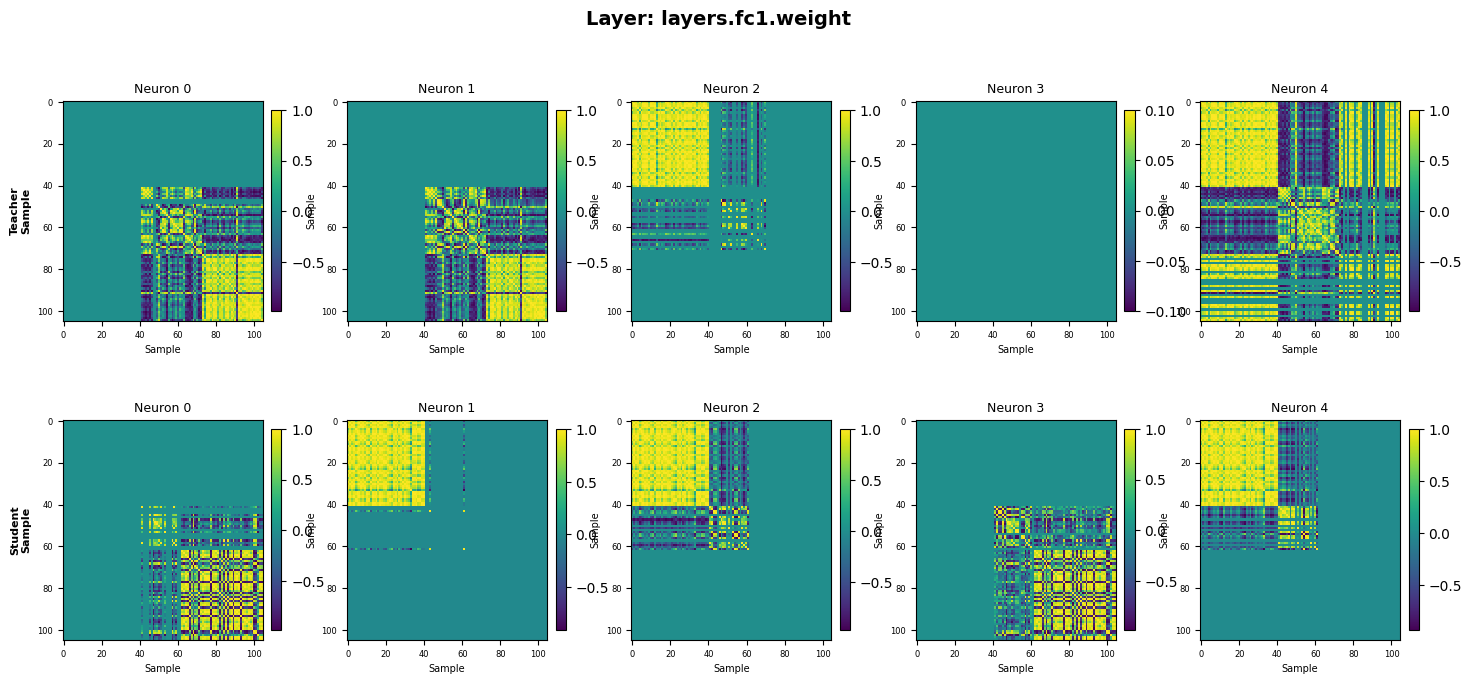

Saved: prof55student5_v2_layers.fc1.weight.png


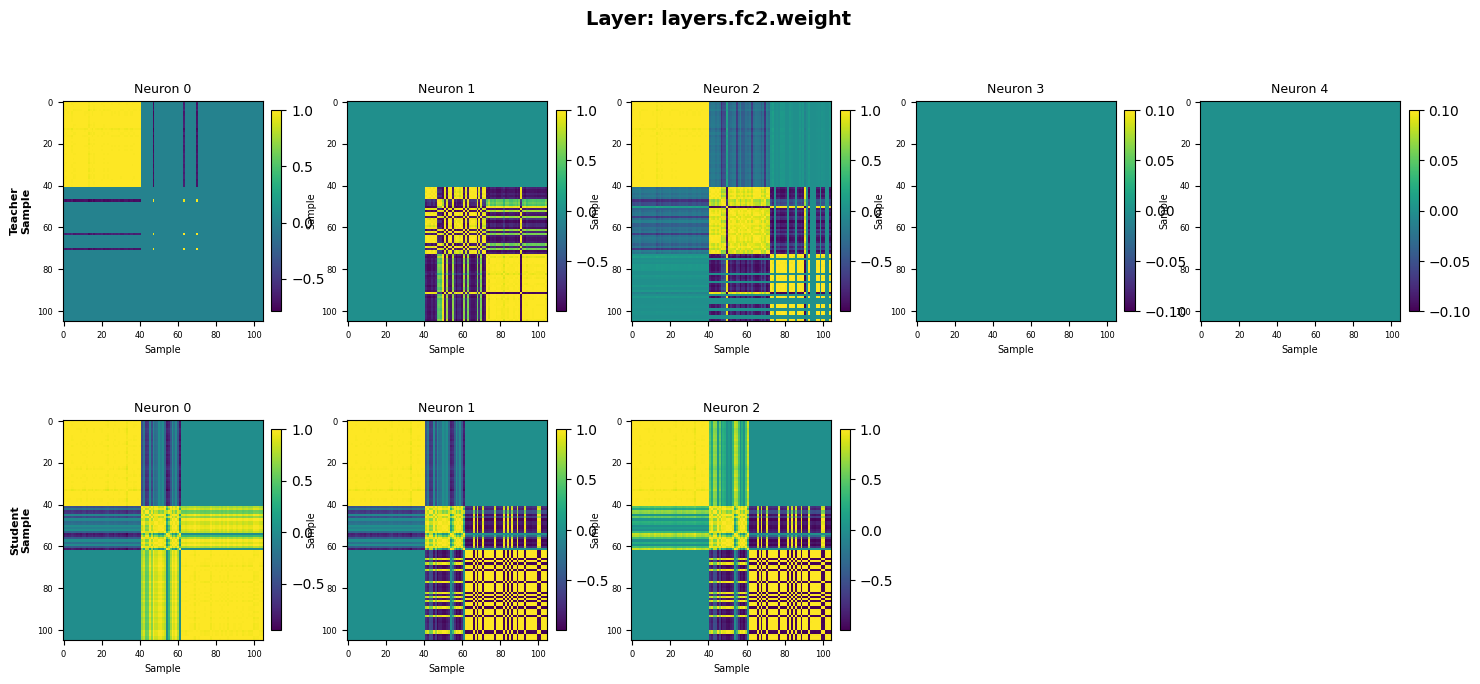

Saved: prof55student5_v2_layers.fc2.weight.png


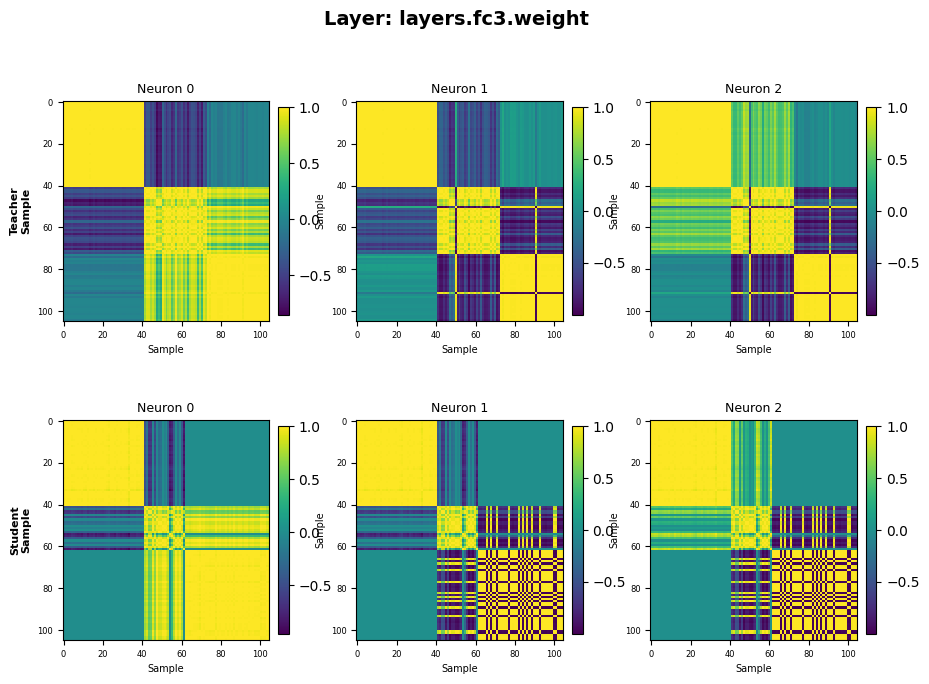

Saved: prof55student5_v2_layers.fc3.weight.png


In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, fname):
    """
    Plots similarity matrices for each neuron of each layer,
    comparing teacher (left) vs student (right).

    Args:
        teacher_sim_matrix: dict {layer_key: tensor of shape (N_teacher, nsamples, nsamples)}
        student_sim_matrix: dict {layer_key: tensor of shape (N_student, nsamples, nsamples)}
    """
    for layer_key in teacher_sim_matrix:
        t_mats = teacher_sim_matrix[layer_key]  # (N_t, S, S)
        if layer_key in student_sim_matrix:
            s_mats = student_sim_matrix[layer_key]  # (N_s, S, S)

        # Convert to numpy if tensors
        if hasattr(t_mats, 'cpu'):
            t_mats = t_mats.cpu().numpy()
            if layer_key in student_sim_matrix:
                s_mats = s_mats.cpu().numpy()

        n_teacher = t_mats.shape[0]
        n_student = s_mats.shape[0]
        n_cols    = max(n_teacher, n_student)

        fig = plt.figure(figsize=(3.5 * n_cols, 7))
        fig.suptitle(f"Layer: {layer_key}", fontsize=14, fontweight='bold', y=1.01)

        # Two rows: teacher on top, student on bottom
        outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.45)

        for row_idx, (label, mats, n_neurons) in enumerate([
            ("Teacher", t_mats, n_teacher),
            ("Student", s_mats, n_student),
        ]):
            inner = gridspec.GridSpecFromSubplotSpec(
                1, n_cols, subplot_spec=outer[row_idx], wspace=0.3
            )

            for neuron_idx in range(n_cols):
                ax = fig.add_subplot(inner[neuron_idx])

                if neuron_idx < n_neurons:
                    mat = mats[neuron_idx]
                    vmin, vmax = mat.min(), mat.max()
                    im = ax.imshow(mat, aspect='auto', cmap='viridis',
                                   vmin=vmin, vmax=vmax, interpolation='nearest')
                    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
                    ax.set_title(f"Neuron {neuron_idx}", fontsize=9)
                    ax.set_xlabel("Sample", fontsize=7)
                    ax.set_ylabel("Sample", fontsize=7)
                    ax.tick_params(labelsize=6)
                else:
                    # Pad empty slots so grids align between teacher/student
                    ax.axis('off')
                    ax.set_facecolor('#f0f0f0')

                # Row label only on the first column
                if neuron_idx == 0:
                    ax.set_ylabel(f"{label}\nSample", fontsize=8, fontweight='bold')

        plt.tight_layout()
        plt.savefig(f"{fname}_{layer_key}.png", dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fname}_{layer_key}.png")


# ── run ───────────────────────────────────────────────────────────────────────
plot_sim_matrices(teacher_sim_matrix, student_sim_matrix, "prof55student5_v2")